In [1]:
# -------------------------------------------------------------------
# Setup project path for module imports
# -------------------------------------------------------------------
#
# This step ensures that the reserbugs package (located in the "src/"
# directory of the repository) can be imported when running this
# notebook from within the "notebooks/" folder.
#
# If the reserbugs source code is not installed as a package, we
# manually add the "src/" directory to the Python path.
#
# This allows imports such as:
#
#   from reserbugs.data import CopernicusDataRetriever
#
# to work correctly.
#
# -------------------------------------------------------------------

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / "src"))

In [2]:
# -------------------------------------------------------------------
# Import required libraries
# -------------------------------------------------------------------
#
# This section imports the main Python libraries used throughout
# the notebook:
#
# - numpy: numerical operations
# - pandas: data manipulation and analysis
# - pickle: saving and loading Python objects
# - plotly: interactive visualization
#
# -------------------------------------------------------------------

import numpy as np
import pandas as pd
import pickle
import plotly.graph_objects as go

In [3]:
# ---------------------------------------------------------------------
# Load selected time series from the BioTIME dataset (sample)
# ---------------------------------------------------------------------
# This dataset contains annual summaries of insect species abundance
# derived from the BioTIME database.
#
# The version included in this repository is a **processed sample**
# dataset, extracted and formatted for use in the reserBUGS examples.
#
# The data have been pre-filtered to include populations with at least
# ten consecutive years of observations, ensuring sufficient temporal
# continuity for forecasting and trend analysis.
#
# The file:
#
#   series_4_RESERBUGS_EXAMPLES.csv
#
# contains, at minimum, the following columns:
#
#   - YEAR        : year of observation
#   - LATITUDE    : latitude of the sampling site
#   - LONGITUDE   : longitude of the sampling site
#   - STUDY_ID    : identifier of the BioTIME study
#   - valid_name  : accepted species name
#
# The resulting DataFrame (df_biotime) is used to:
#
#   - identify unique locations (sites)
#   - define temporal coverage
#   - support retrieval of corresponding abiotic (climate) data
#
# ---------------------------------------------------------------------

# Define input path
input_path = Path("../data/sample/series_4_RESERBUGS_EXAMPLES.csv")

# Load dataset
df_biotime = pd.read_csv(input_path)

In [4]:
# ---------------------------------------------------------------------
# Inspect raw BioTIME dataset (first rows)
# ---------------------------------------------------------------------
# Display the first observations of the original dataset.
#
# Note:
#   The raw data may contain:
#     • multiple entries for the same species × site × year
#       (e.g., repeated samples or subsampling within a year)
#     • an unequal number of observations per year
#     • missing years (irregular time series)
#
#   These issues require preprocessing (aggregation and gap filling)
#   before applying time series models.

df_biotime.head(40)

,STUDY_ID,valid_name,LATITUDE,LONGITUDE,ABUNDANCE,YEAR
0,604,Perizoma alchemillata,60.32200,24.519000,23,1996
1,604,Perizoma alchemillata,60.32200,24.519000,9,1997
2,604,Perizoma alchemillata,60.32200,24.519000,15,1999
3,604,Perizoma alchemillata,60.32200,24.519000,41,2000
4,604,Perizoma alchemillata,60.32200,24.519000,10,2001
5,604,Perizoma alchemillata,60.32200,24.519000,17,2002
6,604,Perizoma alchemillata,60.32200,24.519000,10,2003
7,604,Perizoma alchemillata,60.32200,24.519000,116,2004
8,604,Perizoma alchemillata,60.32200,24.519000,78,2005
9,604,Perizoma alchemillata,60.32200,24.519000,141,2006


In [5]:
# ---------------------------------------------------------------------
# Aggregate raw BioTIME data to one observation per species × site × year
# ---------------------------------------------------------------------
# The original BioTIME dataset may contain multiple rows for the same:
#     • STUDY_ID      (study/project)
#     • valid_name    (species)
#     • LATITUDE
#     • LONGITUDE
#     • YEAR
#
# These repeated rows typically arise from:
#     - multiple samples within the same site and year (e.g., transects, quadrats)
#     - subsampling or replicate measurements
#
# For time series forecasting, we require a *single abundance value per year*
# for each species × site combination. Therefore, we aggregate the data by:
#     (STUDY_ID, valid_name, LATITUDE, LONGITUDE, YEAR)
#
# We use `sum` for ABUNDANCE because:
#     - it represents the total annual abundance at that site
#     - it is the standard approach when combining counts from multiple samples
#
# The resulting dataframe ensures:
#     • one row = one species × site × year
#     • consistent input for time series models
# ---------------------------------------------------------------------

df_biotime_agg = (
    df_biotime
    .groupby(["STUDY_ID", "valid_name", "LATITUDE", "LONGITUDE", "YEAR"], as_index=False)
    .agg({"ABUNDANCE": "sum"})
)

In [6]:
# ---------------------------------------------------------------------
# Inspect aggregated BioTIME dataset
# ---------------------------------------------------------------------
# Display data after aggregating duplicate observations per year:
#   • one row per species × site × year
#   • ABUNDANCE summed across samples within the same year
#
# Note:
#   Missing years are not yet filled at this stage.

df_biotime_agg

,STUDY_ID,valid_name,LATITUDE,LONGITUDE,YEAR,ABUNDANCE
0,597,Aporophyla lutulenta,51.80342,-0.372683,2003,5
1,597,Aporophyla lutulenta,51.80342,-0.372683,2004,8
2,597,Aporophyla lutulenta,51.80342,-0.372683,2005,33
3,597,Aporophyla lutulenta,51.80342,-0.372683,2006,16
4,597,Aporophyla lutulenta,51.80342,-0.372683,2007,2
5,597,Aporophyla lutulenta,51.80342,-0.372683,2008,6
6,597,Aporophyla lutulenta,51.80342,-0.372683,2009,27
7,597,Aporophyla lutulenta,51.80342,-0.372683,2010,1
8,597,Aporophyla lutulenta,51.80342,-0.372683,2011,1
9,597,Aporophyla lutulenta,51.80342,-0.372683,2013,1


In [7]:
def fill_missing_years(group, study_id, valid_name, lat, lon):
    """
    Ensure a continuous annual time series by filling missing years with zero abundance.

    This function takes a single species × site time series (already aggregated
    to one row per year) and inserts any missing years between the first and last
    observation. Missing years are assumed to have ABUNDANCE = 0.

    Parameters
    ----------
    group : pd.DataFrame
        Data for one time series (unique combination of STUDY_ID, valid_name,
        LATITUDE, LONGITUDE). Must contain at least:
            - YEAR
            - ABUNDANCE
        Assumes data are already aggregated to one row per year.
    
    study_id : int or str
        Identifier of the study (constant within group).
    
    valid_name : str
        Scientific name of the species (constant within group).
    
    lat : float
        Latitude of the site (constant within group).
    
    lon : float
        Longitude of the site (constant within group).

    Returns
    -------
    group_filled : pd.DataFrame
        DataFrame with:
            - continuous sequence of years from min(YEAR) to max(YEAR)
            - missing years filled with ABUNDANCE = 0
            - metadata columns (STUDY_ID, valid_name, LATITUDE, LONGITUDE)
              restored for all rows

    Notes
    -----
    - This step is essential for time series models that assume regular temporal spacing.
    - Filling with zero implies that absence of records corresponds to zero abundance,
      which is appropriate for many ecological count datasets but may not always hold.
    - Only *internal gaps* are filled (no extrapolation beyond observed year range).
    """
    # Create a complete sequence of years for this time series
    full_years = pd.DataFrame({
        "YEAR": range(group["YEAR"].min(), group["YEAR"].max() + 1)
    })

    # Merge with observed data (missing years will produce NaNs)
    group_filled = full_years.merge(group, on="YEAR", how="left")

    # Reassign metadata (constant within group)
    group_filled["STUDY_ID"] = study_id
    group_filled["valid_name"] = valid_name
    group_filled["LATITUDE"] = lat
    group_filled["LONGITUDE"] = lon

    # Replace missing abundances (years with no observations) with zero
    group_filled["ABUNDANCE"] = group_filled["ABUNDANCE"].fillna(0)

    return group_filled

In [8]:
# ---------------------------------------------------------------------
# Fill missing years for each species × site time series
# ---------------------------------------------------------------------
# For each unique combination of:
#   (STUDY_ID, valid_name, LATITUDE, LONGITUDE)
#
# this step:
#   • ensures a continuous sequence of years between min(YEAR) and max(YEAR)
#   • fills missing years with ABUNDANCE = 0
#
# This is necessary because:
#   - time series models assume regular time steps
#   - missing years would otherwise break temporal consistency
#
# Implementation details:
#   • group data by species × site
#   • apply `fill_missing_years()` to each group
#   • pass group identifiers explicitly (future-proof with include_groups=False)
#
# Result → `df_biotime_filled`:
#   panel dataset with one row per species × site × year,
#   with no gaps in the time dimension

df_biotime_filled = (
    df_biotime_agg
    .groupby(["STUDY_ID", "valid_name", "LATITUDE", "LONGITUDE"], group_keys=False)
    .apply(
        lambda g: fill_missing_years(
            g,
            g.name[0],  # STUDY_ID
            g.name[1],  # valid_name
            g.name[2],  # LATITUDE
            g.name[3],  # LONGITUDE
        ),
        include_groups=False
    )
    .reset_index(drop=True)
)

In [9]:
# ---------------------------------------------------------------------
# Inspect processed BioTIME dataset
# ---------------------------------------------------------------------
# Display the final dataset after:
#   • aggregating duplicate records per year
#   • filling missing years with ABUNDANCE = 0
#
# Result:
#   one row per species × site × year, with a continuous time series

df_biotime_filled

,YEAR,ABUNDANCE,STUDY_ID,valid_name,LATITUDE,LONGITUDE
0,2003,5.0,597,Aporophyla lutulenta,51.80342,-0.372683
1,2004,8.0,597,Aporophyla lutulenta,51.80342,-0.372683
2,2005,33.0,597,Aporophyla lutulenta,51.80342,-0.372683
3,2006,16.0,597,Aporophyla lutulenta,51.80342,-0.372683
4,2007,2.0,597,Aporophyla lutulenta,51.80342,-0.372683
5,2008,6.0,597,Aporophyla lutulenta,51.80342,-0.372683
6,2009,27.0,597,Aporophyla lutulenta,51.80342,-0.372683
7,2010,1.0,597,Aporophyla lutulenta,51.80342,-0.372683
8,2011,1.0,597,Aporophyla lutulenta,51.80342,-0.372683
9,2012,0.0,597,Aporophyla lutulenta,51.80342,-0.372683


In [10]:
# ---------------------------------------------------------------------
# Build site dictionary for Copernicus data retrieval
# ---------------------------------------------------------------------
# This block prepares the input required by the CopernicusDataRetriever class.
# Each unique combination of latitude and longitude represents one site.
# For every site, we extract:
#   • The minimum and maximum year available in the dataset
#   • The geographic coordinates (latitude, longitude)
# The result is a dictionary that maps a site identifier (e.g., "site_1")
# to its spatial and temporal coverage information.
# ---------------------------------------------------------------------

# 1 Group the dataframe by unique coordinate pairs
#    and determine the earliest and latest year of data for each site.
sites = (
    df_biotime_filled.groupby(["LATITUDE", "LONGITUDE"])
      .agg(
          min_year=("YEAR", "min"),   # first available year at this location
          max_year=("YEAR", "max")    # last available year at this location
      )
      .reset_index()  # convert grouped index back into columns
)

# 2 Build the values_dict expected by CopernicusDataRetriever
#    Each site receives a unique name (e.g., site_1, site_2, ...)
#    and stores the year range plus the coordinates.
values_dict = {
    f"site_{i+1}": {
        "min_year": int(row["min_year"]),
        "max_year": int(row["max_year"]),
        "latitude": float(row["LATITUDE"]),
        "longitude": float(row["LONGITUDE"])
    }
    for i, row in sites.iterrows()
}

# 3 Print the resulting dictionary to verify structure
# Example output:
# {
#   'site_1': {'min_year': 2000, 'max_year': 2010, 'latitude': 51.23, 'longitude': -0.12},
#   'site_2': {'min_year': 1998, 'max_year': 2008, 'latitude': 52.10, 'longitude': -1.45},
#   ...
# }
print(values_dict)

{'site_1': {'min_year': 2003, 'max_year': 2015, 'latitude': 51.80342, 'longitude': -0.372683}, 'site_2': {'min_year': 1996, 'max_year': 2016, 'latitude': 60.322, 'longitude': 24.519}, 'site_3': {'min_year': 1999, 'max_year': 2016, 'latitude': 62.192, 'longitude': 25.861}}


In [11]:
# ---------------------------------------------------------------------
# Retrieve monthly abiotic data from the Copernicus Climate Data Store
# ---------------------------------------------------------------------
# Initialize the CopernicusDataRetriever using the site dictionary built
# earlier (values_dict). Each entry in values_dict represents one unique
# sampling site defined by latitude, longitude, and its observation period
# (min_year → max_year).
#
# The retriever connects to the Copernicus Climate Data Store (CDS)
# and downloads monthly averaged ERA5 climate variables for each site.
# By default, it retrieves:
#   • 2m_temperature
#   • total_precipitation
#   • 10m_u_component_of_wind
#   • 10m_v_component_of_wind
#   • volumetric_soil_water_layer_1–4
# and any other variables specified inside the retriever class.
#
# Notes:
#   • One API call is made per site (→ 13 total requests here).
#   • Each request returns a pandas DataFrame with monthly values.
#   • The result is stored inside a nested dictionary (results), where:
#       results['site_1']['climate_data'] contains the monthly data
#         for that site, with columns such as:
#           valid_time, latitude, longitude, 2m_temperature, total_precipitation, ...
# ---------------------------------------------------------------------


In [12]:
# ---------------------------------------------------------------------
# Import Copernicus data retriever
# ---------------------------------------------------------------------
# CopernicusDataRetriever provides an interface to download climate data
# (e.g., temperature, precipitation, wind) from the Copernicus Climate
# Data Store for a set of geographic locations.

from reserbugs.data import CopernicusDataRetriever

In [13]:
# ---------------------------------------------------------------------
# Retrieve monthly climate data from Copernicus
# ---------------------------------------------------------------------
# Initialize the Copernicus data retriever with site information.
# `values_dict` contains the list of sites with their coordinates
# and requested variables.

retriever = CopernicusDataRetriever(values_dict)

# Download climate data for each site:
#   • one API request per site
#   • returns monthly time series for all requested variables
#
# Result → `results`: dictionary with one entry per site, containing:
#   - 'climate_data' : DataFrame with monthly climate variables
#   - 'latitude', 'longitude' : site coordinates

results = retriever.retrieve_data(time_scale="monthly")

Retrieving data for site_1


2026-03-30 16:10:21,358 INFO Request ID is 1af90f15-aa75-4635-bdfc-dab54698d4d5
2026-03-30 16:10:21,454 INFO status has been updated to accepted
2026-03-30 16:10:54,859 INFO status has been updated to successful


714e1332154f57c74e2b31e89e0e1be1.zip:   0%|          | 0.00/147k [00:00<?, ?B/s]

Retrieving data for site_2


2026-03-30 16:10:56,787 INFO Request ID is 47a9a3f6-bf54-49ab-b642-6027ad4bcf5e
2026-03-30 16:10:56,859 INFO status has been updated to accepted
2026-03-30 16:11:05,267 INFO status has been updated to running
2026-03-30 16:11:10,391 INFO status has been updated to successful


b0adac9595d40089e8fea869b737cc8d.zip:   0%|          | 0.00/161k [00:00<?, ?B/s]

Retrieving data for site_3


2026-03-30 16:11:11,493 INFO Request ID is 3a345eb0-81b2-450d-8933-b5b7e1745a32
2026-03-30 16:11:11,785 INFO status has been updated to accepted
2026-03-30 16:11:20,199 INFO status has been updated to running
2026-03-30 16:11:25,326 INFO status has been updated to successful


ca29f3421668e3248fde66bdff75aaca.zip:   0%|          | 0.00/159k [00:00<?, ?B/s]

In [14]:
# ---------------------------------------------------------------------
# Inspect example site (site_1)
# ---------------------------------------------------------------------
# Display the raw monthly climate data for a single site.
# This helps verify structure, variables, and temporal coverage.

results['site_1']['climate_data']

,valid_time,latitude,longitude,tp,u10,v10,t2m,slt,swvl1,swvl2,swvl3,swvl4,lai_hv,lai_lv
0,2003-01-01,51.75,-0.25,0.002220,2.265724,-0.039589,277.575684,4.0,0.438941,0.442656,0.458599,0.450134,2.173706,2.130615
1,2003-02-01,51.75,-0.25,0.001213,-0.421802,0.915930,277.134521,4.0,0.432438,0.437638,0.443134,0.452805,2.091675,1.917114
2,2003-03-01,51.75,-0.25,0.000654,-0.014663,0.824133,280.650391,4.0,0.392498,0.402664,0.418825,0.450119,2.131836,2.018433
3,2003-04-01,51.75,-0.25,0.000988,-0.869760,0.105285,282.643799,4.0,0.310402,0.307957,0.360232,0.442383,2.253296,2.370728
4,2003-05-01,51.75,-0.25,0.001778,2.260495,2.086631,285.568359,4.0,0.350824,0.313886,0.338962,0.432022,2.382935,2.781616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,2015-08-01,51.75,-0.25,0.003450,0.704267,1.302982,290.005371,4.0,0.376058,0.364561,0.291461,0.399475,2.192139,2.048828
152,2015-09-01,51.75,-0.25,0.002193,0.097017,-0.358702,286.012451,4.0,0.413938,0.409091,0.328400,0.395004,2.156494,1.964600
153,2015-10-01,51.75,-0.25,0.001789,-0.370341,-0.365851,284.358398,4.0,0.407507,0.403220,0.351966,0.392517,2.142090,1.938110
154,2015-11-01,51.75,-0.25,0.002054,3.811346,2.331008,283.118164,4.0,0.439724,0.436982,0.398119,0.392044,2.171875,2.076660


In [15]:
# ---------------------------------------------------------------------
# Combine climate data from all sites into a single dataset
# ---------------------------------------------------------------------
# Each entry in `results` contains:
#   - monthly climate data (`climate_data`)
#   - site metadata (latitude, longitude)
#
# For each site:
#   • copy the climate data
#   • add site identifier and spatial coordinates
#   • append to a list for later concatenation

all_sites = []

for site, info in results.items():
    df = info["climate_data"].copy()
    df["site_id"] = site
    df["latitude"] = info["latitude"]
    df["longitude"] = info["longitude"]
    all_sites.append(df)

# Combine all site-level data into a single DataFrame
# Result → `df_all`: one row per site × time step (monthly resolution)
df_all = pd.concat(all_sites, ignore_index=True)

In [16]:
# ---------------------------------------------------------------------
# Save combined dataset with abiotic variables (Copernicus)
# ---------------------------------------------------------------------
# This block saves the final dataset used for forecasting, which
# combines biological time series (e.g., species abundance) with
# abiotic variables retrieved from Copernicus (ERA5).
#
# The dataset typically includes:
#   - response variable (e.g., ABUNDANCE)
#   - temporal information (e.g., YEAR or DATE)
#   - climatic predictors (e.g., temperature, precipitation, wind)
#
# The file is saved in the "outputs/abiotic_data" directory and can
# be reused for:
#
#   - model training and forecasting
#   - exploratory data analysis
#   - reproducibility of the workflow
#
# The file name:
#
#   series_4_RESERBUGS_EXAMPLES_copernicus_monthly.csv
#
# indicates that it contains monthly abiotic variables retrieved
# from Copernicus for the example dataset.
#
# The CSV format is used for portability and easy inspection.
# ---------------------------------------------------------------------

# Define output path
output_path = Path("../outputs/abiotic_data/series_4_RESERBUGS_EXAMPLES_copernicus_monthly.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save dataset to CSV (without row index)
df_all.to_csv(output_path, index=False)

In [18]:
# ---------------------------------------------------------------------
# Load monthly climate data retrieved from the Copernicus CDS
# ---------------------------------------------------------------------
# This dataset contains monthly abiotic variables retrieved from ERA5
# and ERA5-Land data products using the CopernicusDataRetriever for
# each BioTIME sampling site.
#
# The file:
#
#   biotime_copernicus_monthly_all_sites.csv
#
# is a combined dataset for all sites included in the example workflow,
# where each row represents one monthly observation for a specific
# geographic location.
#
# Included abiotic variables (ERA5):
#   - t2m   : 2-meter air temperature (K)
#   - tp    : mean daily precipitation for the month (m/day; cumulative variable)
#   - u10   : 10-meter zonal (east-west) wind component (m/s)
#   - v10   : 10-meter meridional (north-south) wind component (m/s)
#
# Included abiotic variables (ERA5-Land / soil moisture):
#   - swvl1 : volumetric soil water, layer 1 (0-7 cm depth)
#   - swvl2 : volumetric soil water, layer 2 (7-28 cm depth)
#   - swvl3 : volumetric soil water, layer 3 (28-100 cm depth)
#   - swvl4 : volumetric soil water, layer 4 (100-289 cm depth)
#
# Included vegetation structure variables (MODIS LAI):
#   - lai_hv : leaf area index of high vegetation
#   - lai_lv : leaf area index of low vegetation
#
# These variables provide environmental context for each insect time
# series. In the workflow, they are later aggregated to annual values
# before being merged with the BioTIME abundance dataset for
# ecological forecasting.
# ---------------------------------------------------------------------

input_path = Path("../outputs/abiotic_data/series_4_RESERBUGS_EXAMPLES_copernicus_monthly.csv")
df_climate = pd.read_csv(input_path)

In [19]:
def aggregate_monthly_to_annual(df):
    """
    Aggregate monthly Copernicus ERA5 climate data into annual summaries.

    Parameters
    ----------
    df : pandas.DataFrame
        Monthly climate dataset containing columns:
        ['valid_time', 'latitude', 'longitude', <climate variables>].

    Returns
    -------
    df_annual : pandas.DataFrame
        Annual aggregated dataset where:
        - 'tp' is converted to monthly accumulated precipitation and summed
        - all other numeric variables are averaged
    """

    # 1 Convert valid_time to datetime
    df["valid_time"] = pd.to_datetime(df["valid_time"])

    # 2 Extract year
    df["year"] = df["valid_time"].dt.year

    # 3 Convert tp (m/day) → monthly total (m)
    df["tp"] = df["tp"] * df["valid_time"].dt.days_in_month

    # 4 Variables to sum (annual cumulative)
    sum_vars = ["tp"]

    # 5 Variables to ignore
    ignore_vars = ["valid_time", "year", "latitude", "longitude", "site_id"]

    # 6 Variables to average
    mean_vars = [
        col for col in df.select_dtypes("number").columns
        if col not in sum_vars + ignore_vars
    ]

    # 7 Aggregation dictionary
    agg_dict = {var: "mean" for var in mean_vars}
    agg_dict.update({var: "sum" for var in sum_vars})

    # 8 Aggregate
    df_annual = (
        df.groupby(["site_id", "year", "latitude", "longitude"], as_index=False)
          .agg(agg_dict)
    )

    return df_annual

In [20]:
# ---------------------------------------------------------------------
# Aggregate monthly climate data to annual resolution
# ---------------------------------------------------------------------
# The function `aggregate_monthly_to_annual(df)`:
#   • extracts the year from the timestamp column `valid_time`
#   • computes annual summaries for each climate variable:
#       - means for state variables (e.g., temperature, wind, vegetation)
#       - totals for flux variables (e.g., precipitation)
#   • groups data by (site_id, year, latitude, longitude)
#
# Result:
#   `df_annual` contains one row per site per year with aggregated
#   climate variables, suitable for time series analysis.
#
# Example variables:
#   - tp       : total precipitation (summed → mm/year)
#   - t2m      : mean 2m air temperature (averaged → °C)
#   - u10      : mean zonal wind component at 10m (m/s)
#   - v10      : mean meridional wind component at 10m (m/s)
#   - lai_hv   : leaf area index (high vegetation)
#   - lai_lv   : leaf area index (low vegetation)

df_annual = aggregate_monthly_to_annual(df_climate)

In [21]:
# ---------------------------------------------------------------------
# Inspect annual climate dataset
# ---------------------------------------------------------------------
# Display the aggregated dataset with one row per site × year,
# including annual summaries of climate variables.

df_annual

,site_id,year,latitude,longitude,u10,v10,t2m,slt,swvl1,swvl2,swvl3,swvl4,lai_hv,lai_lv,tp
0,site_1,2003,51.80342,-0.372683,0.647689,0.599881,283.910298,4.0,0.364393,0.356209,0.359280,0.420644,2.211375,2.207418,0.602673
1,site_1,2004,51.80342,-0.372683,1.602982,0.494405,283.854451,4.0,0.407226,0.403128,0.387960,0.415848,2.211385,2.207418,0.722664
2,site_1,2005,51.80342,-0.372683,1.339732,0.270850,283.753275,4.0,0.398140,0.391222,0.370108,0.391094,2.211375,2.207418,0.593970
3,site_1,2006,51.80342,-0.372683,1.223477,0.837952,284.282251,4.0,0.400178,0.391008,0.373806,0.387943,2.211375,2.207418,0.694315
4,site_1,2007,51.80342,-0.372683,1.540576,0.250853,283.980038,4.0,0.399538,0.400706,0.403119,0.415516,2.211375,2.207418,0.743665
5,site_1,2008,51.80342,-0.372683,1.518076,0.845043,283.486837,4.0,0.413067,0.410220,0.400735,0.422571,2.211385,2.207418,0.747036
6,site_1,2009,51.80342,-0.372683,1.213151,0.842563,283.596090,4.0,0.387191,0.377743,0.367035,0.420533,2.211375,2.207418,0.677645
7,site_1,2010,51.80342,-0.372683,0.748757,-0.206547,282.495072,4.0,0.391847,0.383847,0.385057,0.408742,2.211375,2.207418,0.655235
8,site_1,2011,51.80342,-0.372683,1.455162,1.089556,284.280254,4.0,0.367598,0.354962,0.350164,0.408105,2.211375,2.207418,0.520785
9,site_1,2012,51.80342,-0.372683,1.425238,0.750142,283.157777,4.0,0.416372,0.414858,0.407541,0.400717,2.211385,2.207418,0.937308


In [22]:
# ---------------------------------------------------------------------
# Merge annual climate data with BioTIME annual species abundance data
# ---------------------------------------------------------------------
# The BioTIME dataset `df_biotime` contains:
#   • YEAR            (integer year)
#   • LATITUDE, LONGITUDE  (approximate site coordinates)
#   • ABUNDANCE       (annual insect abundance per species per site)
#
# We merge the datasets by:
#   BioTIME YEAR           ↔ climate year
#   BioTIME coordinates    ↔ climate grid cell coordinates
#
# `how="left"` ensures every BioTIME observation remains in the dataset,
# even if climate data is missing for some years (will result in NaNs).

df_merged = df_biotime_filled.merge(
    df_annual,
    left_on=["YEAR", "LATITUDE", "LONGITUDE"],
    right_on=["year", "latitude", "longitude"],
    how="left"
)

In [23]:
# ---------------------------------------------------------------------
# Select input features for the pollinator abundance model
# ---------------------------------------------------------------------
# This section prepares the dataset for modeling by keeping only the
# relevant predictor and response variables, along with the observation
# date for maintaining temporal order.
#
# Columns used:
#   • Date       → Timestamp of the observation (used to order records)
#   • ABUNDANCE  → Number of pollinators recorded (response variable)
#   • tp         → Total precipitation (mm)
#   • u10, v10   → Zonal and meridional 10 m wind components (m/s)
#   • t2m        → 2 m air temperature (K)
#   • lai_hv     → Leaf area index of high vegetation (m²/m²)
#   • lai_lv     → Leaf area index of low vegetation (m²/m²)
#
# These features combine biotic (insect abundance) and abiotic
# (climate and vegetation) data, providing input variables for
# subsequent statistical or machine-learning models.
# ---------------------------------------------------------------------

features = ['STUDY_ID', 'valid_name', 'YEAR', 'ABUNDANCE', 'tp', 'u10', 'v10', 't2m', 'lai_hv', 'lai_lv','LATITUDE', 'LONGITUDE']

# Keep only the selected columns
merged_data = df_merged[features]

In [24]:
# ---------------------------------------------------------------------
# Identify the number of unique time series in the dataset
# ---------------------------------------------------------------------
# Each time series is defined by a unique combination of:
#   • STUDY_ID        → BioTIME study/project identifier
#   • valid_name      → species scientific name
#   • LATITUDE    → geographic latitude of the sampling site
#   • LONGITUDE   → geographic longitude of the sampling site
#
# These four fields together represent a single species monitored
# at a single location across time. Different species in the same site
# count as different time series; likewise, the same species monitored
# in two locations counts as two distinct time series.
#
# We extract this set of unique series and count how many distinct
# population time series are available for forecasting.
# ---------------------------------------------------------------------

unique_series = merged_data[['STUDY_ID', 'valid_name', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
n_series = unique_series.shape[0]

print(f"Number of unique time series = {n_series}")

Number of unique time series = 3


In [25]:
# ---------------------------------------------------------------------
# Forecast each species × site time series independently
# ---------------------------------------------------------------------
# Each unique combination of:
#     • STUDY_ID       (BioTIME study/project)
#     • valid_name     (species scientific name)
#     • LATITUDE   (site latitude)
#     • LONGITUDE  (site longitude)
# defines one population time series.
#
# For each series:
#   1. Sort observations chronologically.
#   2. Skip short series (< 10 years).
#   3. Use the most recent 5 years as the forecasting test window.
#   4. Train a reservoir computing model (RC) on the remaining years.
#   5. Generate multiple forecast paths (N = 500 simulations).
#   6. Extract predictive summaries:
#         - Median forecast (preferred prediction)
#         - Mean forecast
#         - 5% and 95% quantiles (uncertainty interval)
#   7. Compute:
#         - Type S error (directional / sign error with CI)
#         - Type M error (magnitude exaggeration / shrinkage)
#         - Probabilistic scoring rules:
#             * CRPS (continuous ranked probability score)
#             * DSS  (Dawid–Sebastiani score)
#             * Interval Score (Winkler score)
#   8. Save results immediately to CSV files:
#         • df_hist → historical training data used
#         • df_forecast → final-year forecast performance + uncertainty
#
# This workflow is *crash-safe*:
#    - Results from each completed series are appended immediately.
#    - If processing stops, re-running the script will continue safely.
#
# The reservoir computing forecasting is parallelized internally
# (`n_jobs=-2` uses all available CPU cores minus two reserved for system).
# ---------------------------------------------------------------------

groups = merged_data.groupby(["STUDY_ID", "valid_name", "LATITUDE", "LONGITUDE"])

In [26]:
# ---------------------------------------------------------------------
# Inspect first species × site time series
# ---------------------------------------------------------------------
# Extract the first group from the grouped dataset:
#   - `first_key` identifies the series (STUDY_ID, species, location)
#   - `first_group` contains all observations for that series
#
# This is useful for:
#   • understanding the structure of a single time series
#   • verifying chronological order and data completeness

# Get the first group
first_key, first_group = next(iter(groups))

# Inspect results
print("First group key:", first_key)  # identifier of the time series
print(first_group.head())            # first observations (early years)
print(first_group.tail())            # last observations (recent years)

First group key: (597, 'Aporophyla lutulenta', 51.80342, -0.372683)
   STUDY_ID            valid_name  YEAR  ABUNDANCE        tp       u10  \
0       597  Aporophyla lutulenta  2003        5.0  0.602673  0.647689   
1       597  Aporophyla lutulenta  2004        8.0  0.722664  1.602982   
2       597  Aporophyla lutulenta  2005       33.0  0.593970  1.339732   
3       597  Aporophyla lutulenta  2006       16.0  0.694315  1.223477   
4       597  Aporophyla lutulenta  2007        2.0  0.743665  1.540576   

        v10         t2m    lai_hv    lai_lv  LATITUDE  LONGITUDE  
0  0.599881  283.910298  2.211375  2.207418  51.80342  -0.372683  
1  0.494405  283.854451  2.211385  2.207418  51.80342  -0.372683  
2  0.270850  283.753275  2.211375  2.207418  51.80342  -0.372683  
3  0.837952  284.282251  2.211375  2.207418  51.80342  -0.372683  
4  0.250853  283.980038  2.211375  2.207418  51.80342  -0.372683  
    STUDY_ID            valid_name  YEAR  ABUNDANCE        tp       u10  \
8        5

In [27]:
def prepare_train_test_for_group(group, forecast_steps=5):
    """
    Split a single species × site time series into training and test sets
    for forecasting, and construct feature/target matrices.

    The function takes a grouped dataframe corresponding to one unique
    (STUDY_ID, valid_name, LATITUDE, LONGITUDE) combination and:

        1. Sorts observations chronologically by YEAR
        2. Uses the last `forecast_steps` observations as the test set
        3. Uses all preceding observations as the training set
        4. Separates predictors (X) from the target variable (ABUNDANCE)

    Parameters
    ----------
    group : pd.DataFrame
        Data for a single time series (one species × one site).
        Must contain at least:
            - YEAR
            - ABUNDANCE
        May contain additional predictor variables.

    forecast_steps : int, default=5
        Number of final observations to hold out for evaluation.
        These represent the forecasting horizon.

    Returns
    -------
    X_train : pd.DataFrame
        Predictor variables for the training period.

    X_test : pd.DataFrame
        Predictor variables for the test period.

    y_train : pd.Series
        Target variable (ABUNDANCE) for training.

    y_test : pd.Series
        Target variable (ABUNDANCE) for testing.

    Notes
    -----
    - The split is based on the last `forecast_steps` *observations*,
      not strictly on calendar years. If years are missing, the test
      set may span irregular time intervals unless gaps were filled beforehand.
    
    - Columns removed from predictors:
        YEAR, ABUNDANCE, valid_name, STUDY_ID, LATITUDE, LONGITUDE
      These are excluded because:
        • YEAR is treated as a temporal index, not a predictor
        • ABUNDANCE is the response variable
        • remaining columns are identifiers, not features
    
    - The function returns None for all outputs if the time series
      is too short (length ≤ forecast_steps).

    - It is recommended to run this function after:
        • aggregating duplicate records per year
        • filling missing years (to ensure consistent time steps)
    """

    # Ensure chronological ordering
    group = group.sort_values("YEAR").reset_index(drop=True)

    # Skip series that are too short for train/test split
    if len(group) <= forecast_steps:
        return None, None, None, None

    # Split into training (past) and test (future) segments
    train_data = group.iloc[:-forecast_steps].copy()
    test_data  = group.iloc[-forecast_steps:].copy()

    # Columns not used as predictors
    drop_cols = ["YEAR", "ABUNDANCE", "valid_name", "STUDY_ID", "LATITUDE", "LONGITUDE"]

    # Construct feature matrices and target vectors
    X_train = train_data.drop(columns=drop_cols, errors="ignore")
    y_train = train_data["ABUNDANCE"].copy()

    X_test  = test_data.drop(columns=drop_cols, errors="ignore")
    y_test  = test_data["ABUNDANCE"].copy()

    return X_train, X_test, y_train, y_test

In [28]:
# ---------------------------------------------------------------------
# Prepare training and test data for one time series (example group)
# ---------------------------------------------------------------------
# Split the selected species × site time series into:
#   - training data (historical observations)
#   - test data (last 5 observations for forecasting evaluation)
#
# This also separates:
#   - X : predictor variables
#   - y : target variable (ABUNDANCE)

X_train, X_test, y_train, y_test = prepare_train_test_for_group(
    first_group,
    forecast_steps=5
)

# ---------------------------------------------------------------------
# Inspect results
# ---------------------------------------------------------------------
# Print key elements to verify:
#   - group identifier (first_key)
#   - structure of training/test predictors (X)
#   - values of the target variable (y)

print(first_key)
print(X_train.head())
print(y_train.head())
print(X_test.head())
print(y_test)

(597, 'Aporophyla lutulenta', 51.80342, -0.372683)
         tp       u10       v10         t2m    lai_hv    lai_lv
0  0.602673  0.647689  0.599881  283.910298  2.211375  2.207418
1  0.722664  1.602982  0.494405  283.854451  2.211385  2.207418
2  0.593970  1.339732  0.270850  283.753275  2.211375  2.207418
3  0.694315  1.223477  0.837952  284.282251  2.211375  2.207418
4  0.743665  1.540576  0.250853  283.980038  2.211375  2.207418
0     5.0
1     8.0
2    33.0
3    16.0
4     2.0
Name: ABUNDANCE, dtype: float64
          tp       u10       v10         t2m    lai_hv    lai_lv
8   0.520785  1.455162  1.089556  284.280254  2.211375  2.207418
9   0.937308  1.425238  0.750142  283.157777  2.211385  2.207418
10  0.703121  0.857629  0.292364  282.949748  2.211375  2.207418
11  0.823654  1.094317  1.185989  284.538718  2.211375  2.207418
12  0.695478  1.674465  0.991440  283.987610  2.211375  2.207418
8     1.0
9     0.0
10    1.0
11    2.0
12    3.0
Name: ABUNDANCE, dtype: float64


In [29]:
import pickle
# ---------------------------------------------------------------------
# Save training and test data to disk (serialization)
# ---------------------------------------------------------------------
# This block stores the prepared training and test datasets used in
# the forecasting workflow.
#
# Saving these objects allows the preprocessing steps (e.g., data
# cleaning, feature construction, and splitting) to be skipped in
# future runs, improving efficiency and reproducibility.
#
# The output file is saved in the "outputs/predictions" directory
# and contains the following elements:
#
#   - "y_train":
#       training response variable (target time series)
#
#   - "X_train":
#       training predictor variables (features used for fitting)
#
#   - "X_test":
#       predictor variables for the forecast period
#
#   - "y_test":
#       observed values for the test period (used for evaluation)
#
# The file name:
#
#   series_4_RESERBUGS_TRAINING_TEST_DATA.pkl
#
# indicates that it contains the input data used in the forecasting
# example.
#
# The data are stored using Python's pickle format, which supports
# efficient serialization of complex Python objects.
#
# ---------------------------------------------------------------------

# Define output path
output_path = Path("../outputs/predictions/series_4_RESERBUGS_TRAINING_TEST_DATA.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Store variables in a dictionary
variables = {
    "y_train": y_train,
    "X_train": X_train,
    "X_test": X_test,
    "y_test": y_test
}

# Save to disk
with open(output_path, "wb") as f:
    pickle.dump(variables, f, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
import pickle

# ---------------------------------------------------------------------
# Load precomputed training and test datasets
# ---------------------------------------------------------------------
# This block loads previously saved variables containing the train/test
# split used in the forecasting workflow.
#
# The data are stored in a pickle file located in the
# "outputs/predictions" directory and include:
#
#   - "y_train", "y_test":
#       target variable (ABUNDANCE) for training and test periods
#
#   - "X_train", "X_test":
#       predictor variables used as inputs to the model
#
# Loading these variables avoids recomputing preprocessing steps
# (e.g., data preparation and splitting) and ensures reproducibility
# of the forecasting pipeline.
# ---------------------------------------------------------------------

# Define input path
input_path = Path("../outputs/predictions/series_4_RESERBUGS_TRAINING_TEST_DATA.pkl")

# Load pickle file
with open(input_path, "rb") as f:
    variables = pickle.load(f)

# Extract variables
y_train = variables["y_train"]
y_test  = variables["y_test"]
X_train = variables["X_train"]
X_test  = variables["X_test"]

In [4]:
# ---------------------------------------------------------------------
# Import Reservoir Computing model
# ---------------------------------------------------------------------
# ReservoirComputing implements a reservoir-based time series model
# (similar to Echo State Networks), suitable for nonlinear dynamics.
#
# In this workflow, it is used to:
#   • learn temporal patterns from historical data
#   • generate probabilistic forecasts via simulation (multiple paths)
#   • handle count-like data using appropriate likelihoods (e.g., Tweedie)

from reserbugs.reservoir_computing import ReservoirComputing

In [14]:
# ---------------------------------------------------------------------
# Forecast using Reservoir Computing (RC)
# ---------------------------------------------------------------------
# Train a reservoir computing model on the historical data and generate
# probabilistic forecasts for the test period.
#
# Model:
#   - Reservoir Computing (Echo State Network–like architecture)
#   - `family="tweedie"`: suitable for count data (e.g., abundance)
#
# Forecast:
#   - Generates N simulated forecast paths (trajectories)
#   - Captures predictive uncertainty via Monte Carlo sampling
#
# Key parameters:
#   - reservoir_size : number of hidden units (model capacity)
#   - n_lags         : number of past time steps used as input
#   - N              : number of simulated forecast paths
#   - sr_range       : spectral radius range (controls memory/stability)
#   - lr_range       : leaking rate range (controls update dynamics)
#   - input_scaling_range : input weight scaling (controls signal strength)
#   - base_seed      : ensures reproducibility
#
# Parallelization:
#   - n_jobs=-2 → use all available CPU cores minus 2 (leave resources free)
#
# Outputs:
#   - preds : array of shape (N, T) with simulated forecast paths
#   - stats : additional model diagnostics

rc1 = ReservoirComputing(reservoir_size=2000, family="tweedie")
preds, stats = rc1.sample_paths_parallel(
    X_train, y_train, X_test, Y_init=y_train[-1:],
    n_lags=1, N=500, base_seed=1234,
    sr_range=(0.85, 1.0), lr_range=(0.75, 0.95), input_scaling_range=(0.07, 0.13),
    n_jobs=-2  # use all cores minus 2
)

In [33]:
import pickle

# ---------------------------------------------------------------------
# Define output file path for storing model results
# ---------------------------------------------------------------------
# The output file will be saved inside the "outputs/predictions"
# directory at the root of the repository.
#
# The file name identifies:
#   - the dataset used in the example
#   - the forecasting method (reservoir computing)
#   - that the file contains model outputs
#
# In this case, the output file is:
#
#   series_4_RESERBUGS_EXAMPLES_reservoir_outputs.pkl
#
# The ".pkl" extension indicates that the file will be stored in
# Python's pickle format, which allows complex Python objects such
# as dictionaries, arrays, and metadata to be saved efficiently.
#
# If the target directory does not exist, it will be created
# automatically.
# ---------------------------------------------------------------------

output_path = Path("../outputs/predictions/series_4_RESERBUGS_EXAMPLES_reservoir_outputs.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Save simulation results using pickle
# ---------------------------------------------------------------------
# The pickle file stores a dictionary containing the main outputs
# generated by the forecasting procedure:
#
#   - "preds":
#       simulated forecast paths produced by the reservoir computing
#       model. Each row typically corresponds to one simulated
#       trajectory, and each column to one forecast time step.
#
#   - "stats":
#       additional model diagnostics, summary statistics, or metadata
#       returned by the forecasting function.
#
#   - "config":
#       dictionary containing the main model parameters used to
#       generate the forecasts. This is included to support
#       reproducibility and allow the experiment to be replicated.
#
# Saving these objects allows the results to be reloaded later
# without rerunning the full forecasting procedure, which can be
# useful for:
#
#   - reproducibility
#   - downstream analysis
#   - figure generation
#   - comparison of different model settings
#
# The file is written in binary mode ("wb"), which is required for
# pickle files.
#
# The highest pickle protocol is used to improve efficiency and
# compatibility with large objects.
# ---------------------------------------------------------------------

# Define model configuration (for reproducibility)
config = {
    "reservoir_size": 2000,
    "family": "tweedie",
    "n_lags": 1,
    "N": 500,
    "base_seed": 1234,
    "sr_range": (0.85, 1.0),
    "lr_range": (0.75, 0.95),
    "input_scaling_range": (0.07, 0.13),
}

with open(output_path, "wb") as f:
    pickle.dump(
        {
            "preds": preds,
            "stats": stats,
            "config": config
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

In [34]:
import pickle

# ---------------------------------------------------------------------
# Load previously saved reservoir simulation results
# ---------------------------------------------------------------------
# This block loads the results of a previously executed forecasting
# experiment stored in a pickle file.
#
# The file is expected to be located in the "outputs/predictions"
# directory and contains a dictionary with the following elements:
#
#   - "preds":
#       simulated forecast paths (e.g., shape: N x T), where each row
#       corresponds to a simulated trajectory and each column to a
#       forecast time step.
#
#   - "stats":
#       additional model diagnostics, summary statistics, or metadata
#       generated during the forecasting procedure.
#
#   - "config":
#       dictionary containing the model parameters used to generate
#       the forecasts. This allows the experiment to be reproduced.
#
# Loading these results avoids the need to rerun the forecasting
# model, which can be computationally expensive.
# ---------------------------------------------------------------------

# Define path to stored results
input_path = Path("../outputs/predictions/series_4_RESERBUGS_EXAMPLES_reservoir_outputs.pkl")

# Load pickle file
with open(input_path, "rb") as f:
    data = pickle.load(f)

# Extract stored objects
preds = data["preds"]
stats = data["stats"]
config = data["config"]

In [6]:
# ---------------------------------------------------------------------
# Import visualization and evaluation tools from reserbugs
# ---------------------------------------------------------------------
# Visualization functions:
#   - plot_prediction_vs_ground_truth : forecast vs observations with uncertainty
#   - plot_type_s_errors              : Type S (directional) error
#   - plot_type_s_errors_from_forecast: Type S error for forecast workflows
#   - plot_type_m_errors              : Type M (magnitude) error distributions
#   - plot_scoring_rules              : probabilistic scoring rules over time
#
# Scoring functions:
#   - type_s_error : probability of predicting the wrong direction
#   - type_m_error : magnitude error (log-ratio deviation)
#   - scoring_rules: CRPS, DSS, and Interval Score

from reserbugs.visualization.visualizations import (
    plot_prediction_vs_ground_truth,
    plot_type_s_errors,
    plot_type_s_errors_from_forecast,
    plot_type_m_errors,
    plot_scoring_rules,
)

from reserbugs.evaluation import (
    type_s_error,
    type_m_error,
    scoring_rules,
)

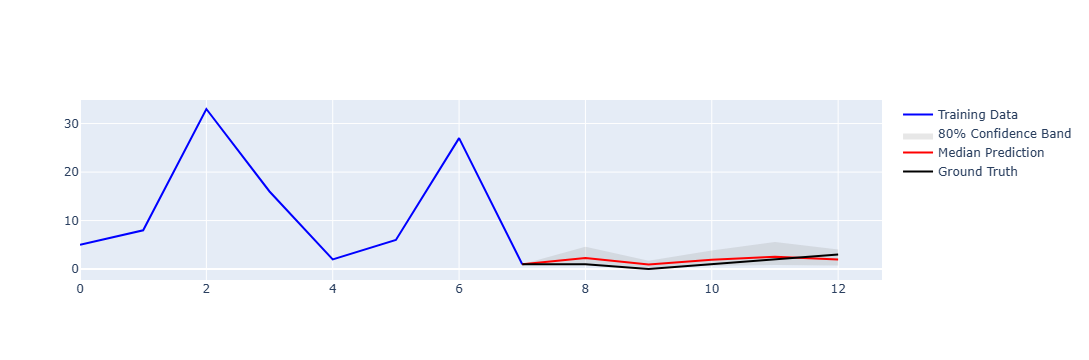

In [15]:
# ---------------------------------------------------------------------
# Plot predictions vs ground truth
# ---------------------------------------------------------------------
# Visualize forecast performance over time:
#   - Training data (historical observations)
#   - Median forecast (central prediction across simulated paths)
#   - Prediction interval (uncertainty band, e.g. 80%)
#   - Ground truth (observed values in the test period)

fig = plot_prediction_vs_ground_truth(
    preds,
    y_train,
    y_test,
    band=80,
    show_paths=False,
    path_alpha=0.35,
    median_color='red',
    gt_color='black'
)

fig.show()

In [37]:
# -------------------------------------------------------------------
# Save interactive Plotly figure (HTML)
# -------------------------------------------------------------------
#
# This block saves the generated Plotly figure as an interactive HTML
# file in the "outputs/figures/" folder at the root of the repository.
#
# The HTML file can be opened in any web browser and retains full
# interactivity (zoom, hover, etc.).
#
# -------------------------------------------------------------------

# Define repository root (one level above notebooks/)
ROOT = Path().resolve().parent

# Define output folder
FIGURES = ROOT / "outputs" / "figures" / "biotime_forecasting"
FIGURES.mkdir(parents=True, exist_ok=True)

# Generate the figure
fig = plot_prediction_vs_ground_truth(
    preds,
    y_train,
    y_test,
    band=80,
    show_paths=False,
    path_alpha=0.35,
    median_color='red',
    gt_color='black'
)

# Save as interactive HTML
fig.write_html(FIGURES / "forecasting_VS_ground_truth.html")

In [16]:
# ---------------------------------------------------------------------
# Prepare inputs for Type S error computation (directional error)
# ---------------------------------------------------------------------

# Extract the last observed value from the training set.
# This will serve as the baseline for evaluating the first forecast step.
last_y = float(y_train.iloc[-1])

# Extend the ground-truth series by prepending the last training value.
# This allows computation of the first change:
#   (y_test[0] - last_y), i.e. the transition from train → test.
y_gt_ext = np.concatenate(([last_y], y_test.values))

# Extend each predicted path in the same way:
# prepend the last training value so that predicted changes are aligned
# with the ground-truth transitions.
preds_ext = np.concatenate(
    (np.full((preds.shape[0], 1), last_y), preds),
    axis=1
)

# ---------------------------------------------------------------------
# Compute Type S error (probability of wrong sign)
# ---------------------------------------------------------------------
# Type S error evaluates whether the model correctly predicts the direction
# of change (increase/decrease) at each forecast step.
#
# With baseline="diff", the comparison is based on first differences:
#   Δy_t = y_t - y_{t-1}
#
# The first forecast step is evaluated relative to the last training value.

error_rate, ci_low, ci_high, x_out, n_valid = type_s_error(
    true_value=y_gt_ext,
    estimate=preds_ext,
    baseline="diff",
    eps=1e-10,
    count_zero_pred_as_error=True,
    return_ci=True,
    alpha=0.05,
    x=y_test.index.values,  # use actual years for x-axis
)

# ---------------------------------------------------------------------
# Inspect results
# ---------------------------------------------------------------------
# Each row corresponds to a forecast horizon (year):
#   - error_rate : probability of wrong sign
#   - ci_low / ci_high : Wilson confidence interval bounds
#   - n_valid : number of prediction paths used (after filtering)
#
# Note: the first horizon may be missing if the true change is zero
# (no defined direction → Type S undefined)

print(pd.DataFrame({
    "x": x_out,
    "error_rate": error_rate,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "n_valid": n_valid
}))

    x  error_rate    ci_low   ci_high  n_valid
0   8         NaN       NaN       NaN        0
1   9       0.002  0.000353  0.011241      500
2  10       0.004  0.001098  0.014466      500
3  11       0.266  0.229160  0.306408      500
4  12       0.934  0.908761  0.952621      500


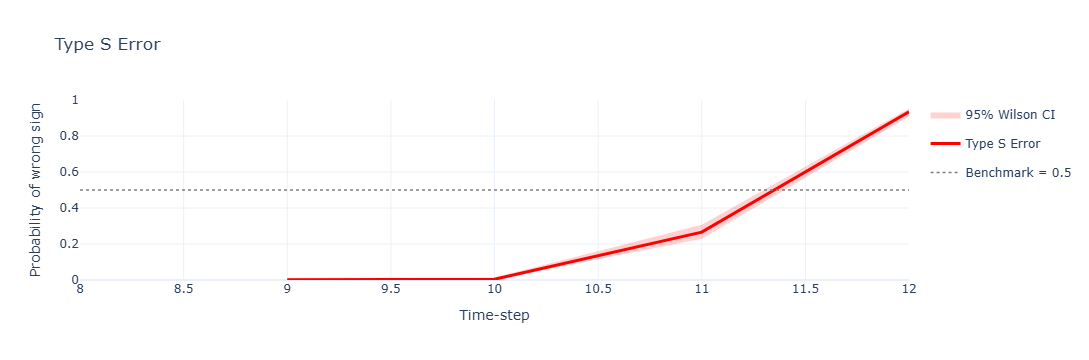

In [9]:
# ---------------------------------------------------------------------
# Plot Type S error (directional error)
# ---------------------------------------------------------------------
# Type S error measures the probability that the model predicts the
# wrong direction of change (increase vs decrease).
#
# Here:
#   - The first forecast step is evaluated relative to the last training value
#   - Subsequent steps compare changes between consecutive time points
#
# The plot shows:
#   - Probability of wrong sign at each forecast step
#   - Optional confidence intervals (Wilson intervals)
#
# Note:
#   If the observed change is zero (no increase/decrease), the Type S error
#   is undefined for that step and may not appear in the plot.

plot_type_s_errors_from_forecast(
    y_train,
    y_test,
    preds)

In [40]:
# -------------------------------------------------------------------
# Save interactive Plotly figure (HTML)
# -------------------------------------------------------------------
#
# This block saves the generated Plotly figure as an interactive HTML
# file in the "outputs/figures/" folder at the root of the repository.
#
# The HTML file can be opened in any web browser and retains full
# interactivity (zoom, hover, etc.).
#
# -------------------------------------------------------------------

# Define repository root (one level above notebooks/)
ROOT = Path().resolve().parent

# Define output folder
FIGURES = ROOT / "outputs" / "figures" / "biotime_forecasting"
FIGURES.mkdir(parents=True, exist_ok=True)

# Generate the figure
fig = plot_type_s_errors_from_forecast(
    y_train,
    y_test,
    preds
)

# Save as interactive HTML
fig.write_html(FIGURES / "type_s_error.html")

In [17]:
# ---------------------------------------------------------------------
# Compute Type M error (magnitude error)
# ---------------------------------------------------------------------
# Type M error measures how much the predicted values deviate in magnitude
# from the observed values on a logarithmic scale:
#
#   Type M = | log_base( prediction / observed ) |
#
# To avoid unrealistic or undefined ratios when values are very small
# or equal to zero, both predicted and observed values below a given
# threshold are replaced by that threshold before computing the error.
#
# Interpretation:
#   - 0   → perfect magnitude match
#   - >0  → over- or under-estimation
#   - larger values → larger multiplicative error
#
# Here:
#   - `estimate` contains N simulated forecast paths (shape: N × T)
#   - `true_value` contains the observed values for the T forecast steps
#
# The function returns:
#   - steps          : forecast horizons (1..T)
#   - per_step_errs  : list of arrays with Type M errors for each step
#   - means          : mean Type M error at each step
# ---------------------------------------------------------------------

steps, per_step_errs, means = type_m_error(
    estimate=preds,
    true_value=y_test,
    threshold=0.1,   # floor for observed/predicted values before log-ratio
    base=10        # log base (interpretation in orders of magnitude)
)

# ---------------------------------------------------------------------
# Inspect results
# ---------------------------------------------------------------------
# `steps`:
#   forecast horizons (1 = first test step, ..., T = last step)
print("steps:", steps)

# `means`:
#   average magnitude error at each step
print("mean Type M error per step:", means)

# `per_step_errs`:
#   full distribution of errors per step (one array per step)
#   useful for violin plots or uncertainty analysis
for step, errs in zip(steps, per_step_errs):
    print(
        f"Step {step}: n_paths={len(errs)}, "
        f"mean={errs.mean():.4f}, std={errs.std():.4f}"
    )

steps: [1 2 3 4 5]
mean Type M error per step: [0.3722316  0.93688516 0.34148518 0.26393085 0.276018  ]
Step 1: n_paths=500, mean=0.3722, std=0.2187
Step 2: n_paths=500, mean=0.9369, std=0.2581
Step 3: n_paths=500, mean=0.3415, std=0.1949
Step 4: n_paths=500, mean=0.2639, std=0.1948
Step 5: n_paths=500, mean=0.2760, std=0.2502


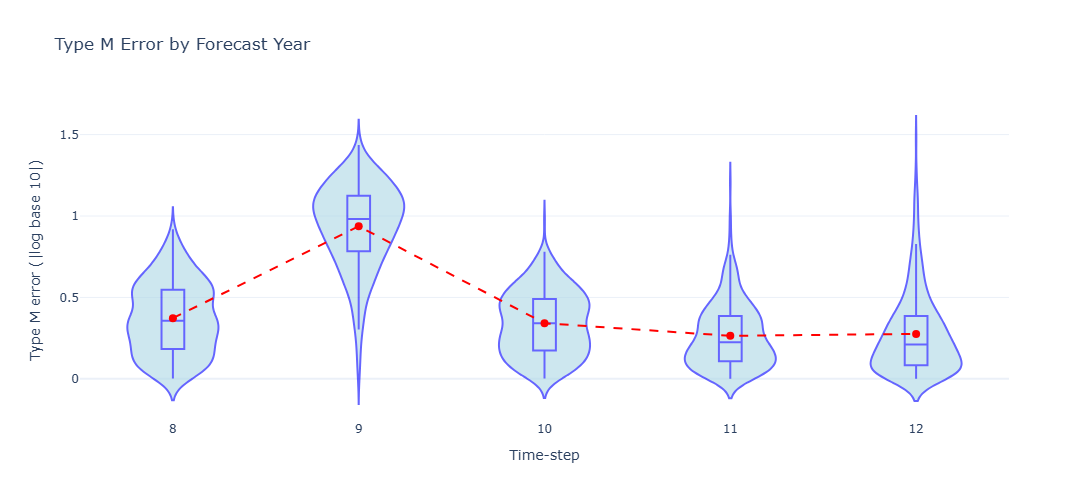

In [18]:
# ---------------------------------------------------------------------
# Plot Type M error (magnitude error) by forecast year
# ---------------------------------------------------------------------
# Visualize how much predictions deviate in magnitude from observations
# at each forecast step.
#
# The plot shows:
#   - Violin distributions: full distribution of Type M errors across
#     all simulated prediction paths (uncertainty)
#   - Red dashed line: mean Type M error at each step
#
# Interpretation:
#   - 0   → perfect magnitude agreement
#   - >0  → over- or under-estimation
#   - larger values → larger multiplicative error (log scale)

fig = plot_type_m_errors(
    true_value=y_test,
    estimate=preds,
    steps=steps,
    per_step_errs=per_step_errs,
    means=means,
    base=10,
    title="Type M Error by Forecast Year"
)

fig.show()

In [43]:
# -------------------------------------------------------------------
# Save interactive Plotly figure (HTML)
# -------------------------------------------------------------------
#
# This block saves the generated Plotly figure as an interactive HTML
# file in the "outputs/figures/" folder at the root of the repository.
#
# The HTML file can be opened in any web browser and retains full
# interactivity (zoom, hover, etc.).
#
# -------------------------------------------------------------------

# Define repository root (one level above notebooks/)
ROOT = Path().resolve().parent

# Define output folder
FIGURES = ROOT / "outputs" / "figures" / "biotime_forecasting"
FIGURES.mkdir(parents=True, exist_ok=True)

# Generate the figure
fig = plot_type_m_errors(
    true_value=y_test,
    estimate=preds,
    steps=steps,
    per_step_errs=per_step_errs,
    means=means,
    base=10,
    title="Type M Error by Forecast Year"
)

# Save as interactive HTML
fig.write_html(FIGURES / "type_m_error.html")

In [19]:
# ---------------------------------------------------------------------
# Compute probabilistic scoring rules for the forecast
# ---------------------------------------------------------------------
# These metrics evaluate the full predictive distribution, not just a
# single point forecast. They assess both accuracy and uncertainty.
#
# Metrics:
#   - CRPS (Continuous Ranked Probability Score):
#       Measures overall agreement between the predictive distribution
#       and the observed value. Lower values indicate better forecasts.
#
#   - DSS (Dawid–Sebastiani Score):
#       Evaluates the forecast using the predictive mean and variance,
#       combining calibration and sharpness. Lower values are better.
#
#   - Interval Score:
#       Evaluates the quality of prediction intervals by rewarding
#       narrow intervals when they contain the observation and penalizing
#       intervals that miss the observed value. Lower values are better.
#
# Here:
#   - `preds` contains N simulated forecast paths (shape: N × T)
#   - `y_test` contains the observed values for the T forecast steps
#
# Note:
#   `y_test` is sliced to match the forecast horizon (preds.shape[1]),
#   ensuring that observed values and prediction paths are aligned.

scores = scoring_rules(
    true_value=y_test[:preds.shape[1]],
    estimate=preds,
    alpha=0.05
)

# ---------------------------------------------------------------------
# Inspect results
# ---------------------------------------------------------------------
# The returned object typically contains one row per forecast step with
# the corresponding scoring-rule values.
# In all three metrics, lower values indicate better predictive performance.

print(scores)

          CRPS       DSS  IntervalScore
step                                   
1     0.868097  2.004388       5.619193
2     0.719493  2.563336      10.602502
3     0.625804  1.329693       4.767481
4     0.491312  1.553823       7.196150
5     0.556496  0.900261       4.829790


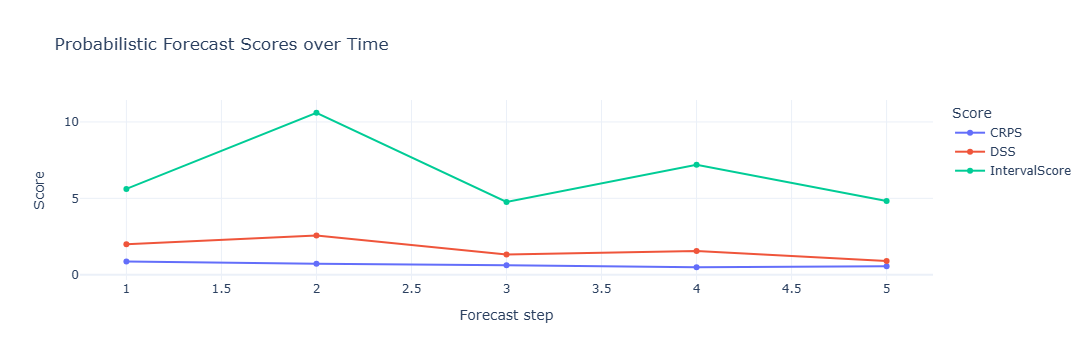

In [13]:
# ---------------------------------------------------------------------
# Plot probabilistic scoring rules by forecast year
# ---------------------------------------------------------------------
# Visualize forecast performance using proper scoring rules:
#   - CRPS: overall agreement between predictive distribution and observations
#   - DSS: evaluates mean and variance (calibration + sharpness)
#   - Interval Score: quality of prediction intervals
#
# The plot shows how these metrics evolve across forecast steps (years).
#
# Interpretation:
#   - Lower values indicate better predictive performance
#   - Differences across steps highlight where forecasts degrade or improve

plot_scoring_rules(scores)

In [46]:
# -------------------------------------------------------------------
# Save interactive Plotly figure (HTML)
# -------------------------------------------------------------------
#
# This block saves the generated Plotly figure as an interactive HTML
# file in the "outputs/figures/" folder at the root of the repository.
#
# The HTML file can be opened in any web browser and retains full
# interactivity (zoom, hover, etc.).
#
# -------------------------------------------------------------------

# Define repository root (one level above notebooks/)
ROOT = Path().resolve().parent

# Define output folder
FIGURES = ROOT / "outputs" / "figures" / "biotime_forecasting"
FIGURES.mkdir(parents=True, exist_ok=True)

# Generate the figure
fig = plot_scoring_rules(scores)

# Save as interactive HTML
fig.write_html(FIGURES / "other_scoring_rules.html")